In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\adeeb\Downloads\etrain_delays.csv")  # upload the file first using the folder icon on the left sidebar
df.head()
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   train_number           1900 non-null   int64  
 1   train_name             1900 non-null   object 
 2   station_code           1900 non-null   object 
 3   station_name           1900 non-null   object 
 4   average_delay_minutes  1664 non-null   float64
 5   pct_right_time         1900 non-null   float64
 6   pct_slight_delay       1900 non-null   float64
 7   pct_significant_delay  1900 non-null   float64
 8   pct_cancelled_unknown  1900 non-null   float64
 9   scraped_at             1900 non-null   object 
 10  source_url             1900 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 163.4+ KB


train_number               0
train_name                 0
station_code               0
station_name               0
average_delay_minutes    236
pct_right_time             0
pct_slight_delay           0
pct_significant_delay      0
pct_cancelled_unknown      0
scraped_at                 0
source_url                 0
dtype: int64

In [3]:
df.duplicated().sum()

np.int64(0)

Before blindly filling in those 236 nulls, let's investigate why they're missing. 
My hypothesis: rows where pct_right_time is 100 (always on time) might have 
no "average delay" computed because there's nothing to average. Let's test that:

In [6]:
df[df['average_delay_minutes'].isnull()][['pct_right_time', 'pct_slight_delay', 'pct_significant_delay', 'pct_cancelled_unknown']].describe()

,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown
count,236.000000,236.000000,236.000000,236.000000
mean,54.878305,30.436017,13.460254,1.224576
std,35.046285,27.626640,21.329401,10.180369
min,0.000000,0.000000,0.000000,0.000000
25%,24.982500,4.000000,0.000000,0.000000
50%,58.040000,23.640000,5.240000,0.000000
75%,88.590000,50.237500,16.085000,0.000000
max,100.000000,100.000000,100.000000,97.810000


So the actual output looks basically like a random slice of the whole dataset, not a special on-time cluster. That's the tell : the hypothesis is rejected. The nulls aren't happening because "no delay to average since always on time.

Now let's test the next hypothesis :  that these nulls happen when the train's status was mostly "cancelled/unknown," so there was no real delay to measure.

In [12]:
df[df['average_delay_minutes'].isnull()]['pct_cancelled_unknown'].value_counts()

pct_cancelled_unknown
0.00     219
0.27       3
0.38       3
4.38       3
0.55       2
0.01       1
83.56      1
0.28       1
90.00      1
97.81      1
1.15       1
Name: count, dtype: int64

219 out of 236 rows (that's 93%!) have pct_cancelled_unknown = 0.00  meaning almost none of these trains were cancelled or had unknown status. If cancellation were the cause of the missing delay, we'd expect the opposite: a high pct_cancelled_unknown for most of these rows. Instead we're seeing the exact reverse.This actually rejects hypothesis #2 as well

let's see if it's tied to a specific train or station, which would point to a scraping failure for that source:

In [22]:
df[df['average_delay_minutes'].isnull()]['station_name'].value_counts().head(20)

station_name
HOWRAH JN                    5
H NIZAMUDDIN                 4
NEW DELHI                    4
ARAKKONAM                    4
GWALIOR                      3
BHOPAL JN                    3
RAICHUR                      3
MANTHRALAYAM RD              3
JOLARPETTAI                  3
VADODARA JN                  3
KISHANGANJ                   3
ANAND VIHAR TRM              3
CHENNAI CENTRAL              3
TIRUPPUR                     3
PT DEEN DAYAL UPADHYAY JN    3
BANDRA TERMINUS              2
DHARMAVARAM JN               2
GODHRA JN                    2
RATANGARH JN                 2
KALABURAGI JN                2
Name: count, dtype: int64

These 236 missing average_delay_minutes values don't correlate with punctuality, cancellation rate, or a specific station. They appear to be scattered, sporadic gaps , most likely a scraping/data recording limitation

In [24]:
df[df['average_delay_minutes'].isnull()]['station_name'].value_counts().head(10)



station_name
HOWRAH JN          5
H NIZAMUDDIN       4
NEW DELHI          4
ARAKKONAM          4
GWALIOR            3
BHOPAL JN          3
RAICHUR            3
MANTHRALAYAM RD    3
JOLARPETTAI        3
VADODARA JN        3
Name: count, dtype: int64

In [35]:
df['average_delay_minutes'] = df['average_delay_minutes'].fillna(df.groupby('station_name')['average_delay_minutes'].transform('median'))

In [36]:
df.isna().sum()

train_number             0
train_name               0
station_code             0
station_name             0
average_delay_minutes    7
pct_right_time           0
pct_slight_delay         0
pct_significant_delay    0
pct_cancelled_unknown    0
scraped_at               0
source_url               0
dtype: int64

In [37]:
df[df['average_delay_minutes'].isnull()]['station_name']

246         PIPARIYA
271         PIPARIYA
1055          KARJAT
1173       CHALAKUDI
1182       CHALAKUDI
1361    RATANGARH JN
1366    RATANGARH JN
Name: station_name, dtype: object

In [40]:
df[df['pct_right_time'] > 90]

,train_number,train_name,station_code,station_name,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown,scraped_at,source_url
0,12673,Cheran Express,MAS,CHENNAI CENTRAL,2.0,98.90,0.27,0.00,0.83,2025-09-27T12:25:37.767628+00:00,https://etrain.info/train/Cheran-Express-12673...
9,12673,Cheran Express,CBE,COIMBATORE JN,2.0,96.16,3.56,0.27,0.01,2025-09-27T12:25:56.853323+00:00,https://etrain.info/train/Cheran-Express-12673...
10,12674,Cheran Express,CBE,COIMBATORE JN,5.0,97.26,2.47,0.27,0.00,2025-09-27T12:26:02.443675+00:00,https://etrain.info/train/Cheran-Express-12674...
14,12674,Cheran Express,JTJ,JOLARPETTAI,7.0,93.15,6.30,0.55,0.00,2025-09-27T12:26:15.876141+00:00,https://etrain.info/train/Cheran-Express-12674...
18,12674,Cheran Express,MAS,CHENNAI CENTRAL,6.0,94.52,3.56,1.37,0.55,2025-09-27T12:26:25.706286+00:00,https://etrain.info/train/Cheran-Express-12674...
...,...,...,...,...,...,...,...,...,...,...,...
1749,15959,Kamrup Express,NFK,NEW FARAKKA JN,9.0,90.04,8.05,1.92,0.00,2025-09-27T20:39:58.489374+00:00,https://etrain.info/train/Kamrup-Express-15959...
1750,15959,Kamrup Express,MLDT,MALDA TOWN,8.0,95.02,3.07,1.92,0.00,2025-09-27T20:40:02.202690+00:00,https://etrain.info/train/Kamrup-Express-15959...
1795,15960,Kamrup Express,DBRG,DIBRUGARH,15.0,96.54,2.69,0.77,0.00,2025-09-27T20:42:10.663692+00:00,https://etrain.info/train/Kamrup-Express-15960...
1804,15960,Kamrup Express,FKG,FURKATING JN,8.0,91.15,6.54,2.31,0.00,2025-09-27T20:42:40.838261+00:00,https://etrain.info/train/Kamrup-Express-15960...


In [41]:
df[df['pct_right_time'] > 90]['station_name']

0        CHENNAI CENTRAL
9          COIMBATORE JN
10         COIMBATORE JN
14           JOLARPETTAI
18       CHENNAI CENTRAL
              ...       
1749      NEW FARAKKA JN
1750          MALDA TOWN
1795           DIBRUGARH
1804        FURKATING JN
1876    TRIVANDRUM NORTH
Name: station_name, Length: 274, dtype: object

In [42]:
df['scraped_at'] = pd.to_datetime(df['scraped_at'])


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   train_number           1900 non-null   int64              
 1   train_name             1900 non-null   object             
 2   station_code           1900 non-null   object             
 3   station_name           1900 non-null   object             
 4   average_delay_minutes  1893 non-null   float64            
 5   pct_right_time         1900 non-null   float64            
 6   pct_slight_delay       1900 non-null   float64            
 7   pct_significant_delay  1900 non-null   float64            
 8   pct_cancelled_unknown  1900 non-null   float64            
 9   scraped_at             1900 non-null   datetime64[ns, UTC]
 10  source_url             1900 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(5), int64(1), object(

sanity check

In [44]:
df['pct_sum_check'] = df['pct_right_time'] + df['pct_slight_delay'] + df['pct_significant_delay'] + df['pct_cancelled_unknown']
df['pct_sum_check'].describe()

count    1900.000000
mean      100.000426
std         0.002592
min        99.990000
25%       100.000000
50%       100.000000
75%       100.000000
max       100.010000
Name: pct_sum_check, dtype: float64

In [45]:
df = df.drop(columns=['pct_sum_check'])

Which stations have the worst average delays?

In [46]:
df.groupby('station_name')['average_delay_minutes'].mean().sort_values(ascending=False).head(10)

station_name
AKOLA JN         429.500
TATANAGAR JN     338.500
BILASPUR JN      299.500
DANKUNI          149.000
RAMPUR HAT       132.000
SAMALKOT JN      126.500
RAJAMUNDRY       124.375
NIDADAVOLU JN    124.000
ANNAVARAM        119.000
TUNI             118.000
Name: average_delay_minutes, dtype: float64

429.5 minutes is over 7 hours of average delay. That's an extreme number,  A very common trap here: a station with only 1 or 2 rows in the whole dataset can produce a wild average just from one freak delay

In [49]:
df.groupby('station_name')['average_delay_minutes'].agg(['mean', 'count']).sort_values('mean' , ascending = False).head(10)

,mean,count
station_name,,
AKOLA JN,429.500,2
TATANAGAR JN,338.500,2
BILASPUR JN,299.500,2
DANKUNI,149.000,2
RAMPUR HAT,132.000,2
SAMALKOT JN,126.500,4
RAJAMUNDRY,124.375,8
NIDADAVOLU JN,124.000,4
ANNAVARAM,119.000,4


applied a minimum-sample threshold of 10 records before ranking stations, to avoid single-outlier distortion

In [54]:
station_stats = df.groupby('station_name')['average_delay_minutes'].agg(['mean', 'count'])
station_stats[station_stats['count'] > 10].sort_values('mean', ascending=False)

,mean,count
station_name,,
C SHIVAJI TERM MUMBAI,70.000000,12
KALYAN JN,67.944444,18
HOWRAH JN,65.750000,20
VIJAYAWADA JN,57.111111,18
KATPADI JN,30.888889,18
ARAKKONAM,29.875000,16
MATHURA JN,29.250000,12
GWALIOR,29.071429,14
THANE,28.285714,14


In [ ]:
does delay vary by train, not just station?

In [84]:
Train_stats = df.groupby('train_name')['average_delay_minutes'].agg(['mean', 'count'])
Train_stats[Train_stats['count'] > 10].sort_values('mean', ascending=False)

,mean,count
train_name,,
Howrah Duronto,308.562500,16
Guwahati Sbc Express,135.768293,41
Howrah Mail,104.366197,142
Sbc Guwahati Express,86.625000,40
Kerala Express,61.152941,85
Coromandel Express,60.828571,35
Duronto Express,55.208333,36
Tamil Nadu Exp,38.200000,25
Vikramshila Express,38.042553,47


In [85]:
howrah_count = df[df['train_name'].str.contains('Howrah', case=False, na=False)]
howrah_count

,train_number,train_name,station_code,station_name,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown,scraped_at,source_url,is_premium,Corridor
132,12839,Howrah Mail,HWH,HOWRAH JN,45.0,36.67,46.67,16.67,0.00,2025-09-27 12:32:29.334699+00:00,https://etrain.info/train/Howrah-Mail-12839/hi...,False,Howrah/Eastern
133,12839,Howrah Mail,KGP,KHARAGPUR JN,68.0,10.00,50.00,40.00,0.00,2025-09-27 12:32:31.151667+00:00,https://etrain.info/train/Howrah-Mail-12839/hi...,False,others
134,12839,Howrah Mail,BLS,BALASORE,87.0,0.00,46.67,53.33,0.00,2025-09-27 12:32:32.933272+00:00,https://etrain.info/train/Howrah-Mail-12839/hi...,False,others
135,12839,Howrah Mail,BHC,BHADRAKH,81.0,16.67,40.00,43.33,0.00,2025-09-27 12:32:34.949490+00:00,https://etrain.info/train/Howrah-Mail-12839/hi...,False,others
136,12839,Howrah Mail,JJKR,JAJPUR K ROAD,90.0,6.67,36.67,56.67,0.00,2025-09-27 12:32:38.776854+00:00,https://etrain.info/train/Howrah-Mail-12839/hi...,False,others
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,12302,Howrah Rajdhani,GAYA,GAYA JN,23.0,73.08,19.23,7.69,0.00,2025-09-27 20:24:55.114592+00:00,https://etrain.info/train/Howrah-Rajdhani-1230...,True,others
1406,12302,Howrah Rajdhani,PNME,PARASNATH,34.0,46.15,46.15,7.69,0.01,2025-09-27 20:24:56.656013+00:00,https://etrain.info/train/Howrah-Rajdhani-1230...,True,others
1407,12302,Howrah Rajdhani,DHN,DHANBAD JN,20.0,88.46,3.85,7.69,0.00,2025-09-27 20:25:00.346652+00:00,https://etrain.info/train/Howrah-Rajdhani-1230...,True,others
1408,12302,Howrah Rajdhani,ASN,ASANSOL JN,40.0,50.00,38.46,11.54,0.00,2025-09-27 20:25:02.160997+00:00,https://etrain.info/train/Howrah-Rajdhani-1230...,True,others


In [99]:
df['is_premium'] = df['train_name'].str.contains('Rajdhani|Vande Bharat|Duronto|Shatabdi', case=False)
df['is_premium']
df.groupby('is_premium')['average_delay_minutes'].agg(['mean', 'count'])

,mean,count
is_premium,,
False,41.366183,1517
True,30.386968,376


findings:

Geographic clustering — Mumbai suburban corridor (CST, Kalyan, Thane) and the Howrah corridor both show elevated delays
Service-tier effect — premium trains (Rajdhani/Vande Bharat/Duronto/Shatabdi) run ~27% less delayed than regular trains

question : does delay vary by time

In [87]:
df['scraped_at'].dt.hour.value_counts().sort_index()

scraped_at
12     223
13     554
19      62
20    1061
Name: count, dtype: int64

What this means for your analysis: scraped_at tells you when the data was collected, not when the train actually ran or was delayed. So we should not attempt any "delay by hour of day" analysis — any pattern we'd find would really just reflect "which scraping batch" the row came from, not real train behavior. That's a trap worth explicitly avoiding, and explicitly stating in your README: "scraped_at reflects collection time, not train arrival time, and was therefore excluded from time-based delay analysis to avoid a misleading conclusion."

In [88]:
mumbai_stations = ['C SHIVAJI TERM MUMBAI', 'KALYAN JN', 'THANE']
howrah_stations = ['HOWRAH JN']
def assign_corridor(station):
    if station in  mumbai_stations:
        return 'Mumbai suburban'
    elif station in  howrah_stations:
        return 'Howrah/Eastern'
    else: 
        return 'others'
df['Corridor'] = df['station_name'].apply(assign_corridor)


In [89]:
df['corridor'].value_counts()

KeyError: 'corridor'

In [91]:
train_stats = df.groupby('train_name')['average_delay_minutes'].agg(['mean', 'count'])

In [92]:
# Station-level flag
station_threshold = station_stats[station_stats['count'] >= 10]['mean'].quantile(0.75)
station_stats['high_delay_station'] = (station_stats['mean'] >= station_threshold) & (station_stats['count'] >= 10)

# Train-level flag
train_threshold = train_stats[train_stats['count'] >= 10]['mean'].quantile(0.75)
train_stats['high_delay_train'] = (train_stats['mean'] >= train_threshold) & (train_stats['count'] >= 10)

In [94]:
station_threshold

np.float64(30.1)

In [95]:
train_threshold

np.float64(36.22857142857143)

In [93]:
station_stats[station_stats['high_delay_station']]

,mean,count,high_delay_station
station_name,,,
BHUBANESWAR,94.500000,10,True
C SHIVAJI TERM MUMBAI,70.000000,12,True
ERODE JN,30.100000,10,True
HOWRAH JN,65.750000,20,True
KALYAN JN,67.944444,18,True
KATPADI JN,30.888889,18,True
NAGPUR,63.700000,10,True
PERAMBUR,43.100000,10,True
VIJAYAWADA JN,57.111111,18,True


In [96]:
train_stats[train_stats['high_delay_train']]

,mean,count,high_delay_train
train_name,,,
Coromandel Express,60.828571,35,True
Devagiri Express,37.070175,57,True
Duronto Express,55.208333,36,True
Guwahati Sbc Express,135.768293,41,True
Howrah Duronto,308.562500,16,True
Howrah Mail,104.366197,142,True
Kerala Express,61.152941,85,True
Sanghamitra Express,36.228571,70,True
Sbc Guwahati Express,86.625000,40,True


In [97]:
df = df.drop(columns=['corridor'], errors='ignore')

In [101]:
def categorize_delay(minutes):
    if minutes <= 15:
        return 'On-time'
    elif minutes <= 60:
        return 'Moderate'
    else:
        return 'Severe'

df['delay_severity'] = df['average_delay_minutes'].apply(categorize_delay)

In [102]:
df['delay_severity'].value_counts()

delay_severity
Moderate    976
On-time     582
Severe      342
Name: count, dtype: int64

the majority of trains in this dataset run at least moderately delayed, not just a few bad apples

In [103]:
pd.crosstab(df['is_premium'], df['delay_severity'])

delay_severity,Moderate,On-time,Severe
is_premium,,,
False,839,368,315
True,137,214,27


Premium trains (True): 214/378 (~57%) are On-time, only 27 (~7%) are Severe
Regular trains (False): only 368/1,491 (~25%) are On-time, while 315 (~21%) are Severe

Worth checking whether severely delayed trains also tend to have higher cancellation/unknown rates

In [104]:
df.groupby('delay_severity')['pct_cancelled_unknown'].mean()

delay_severity
Moderate    1.193094
On-time     1.385670
Severe      0.762485
Name: pct_cancelled_unknown, dtype: float64

cancellation rate does not increase with delay severity , possibly because cancelled services are logged before a delay accumulates, rather than because cancellations are unrelated to poor performance.

In [105]:
pd.crosstab(df['station_name'], df['delay_severity'])

delay_severity,Moderate,On-time,Severe
station_name,,,
ABHAIPUR,2,0,0
ABU ROAD,0,2,0
ADONI,7,0,1
AGRA CANTT,9,4,1
AHMADNAGAR,0,0,2
...,...,...,...
WARANGAL,3,1,4
YADGIR,5,1,0
YAMUNANAGAR JAGADHRI,1,1,0


In [106]:
pd.crosstab(df['station_name'], df['delay_severity']).loc[station_stats[station_stats['high_delay_station']].index]

delay_severity,Moderate,On-time,Severe
station_name,,,
BHUBANESWAR,2,0,8
C SHIVAJI TERM MUMBAI,3,7,2
ERODE JN,7,2,1
HOWRAH JN,9,6,5
KALYAN JN,13,3,2
KATPADI JN,8,8,2
NAGPUR,7,1,2
PERAMBUR,7,2,1
VIJAYAWADA JN,11,1,6


Which trains are the most consistent (low variation) vs unpredictable (high variation) in delay?



In [107]:
df.groupby('train_name')['average_delay_minutes'].agg(['mean', 'std', 'count'])
train_consistency = df.groupby('train_name')['average_delay_minutes'].agg(['mean', 'std', 'count'])
train_consistency[train_consistency['count'] >= 10].sort_values('std', ascending=False).head(10)

,mean,std,count
train_name,,,
Howrah Duronto,308.562500,171.561444,16
Guwahati Sbc Express,135.768293,91.827971,41
Sbc Guwahati Express,86.625000,69.334450,40
Duronto Express,55.208333,53.166769,36
Kerala Express,61.152941,41.257469,85
Chennai Intercity,34.989362,27.082902,47
Coromandel Express,60.828571,25.449472,35
Howrah Mail,104.366197,22.829845,142
Vikramshila Express,38.042553,21.700488,47


std (standard deviation) tells you how spread out a train's delays are across its different stations — a high std means a train is wildly inconsistent (sometimes fine, sometimes terrible), while a low std means it's predictably similar everywhere

This is actually a more interesting "advanced" question than raw mean delay, since a train with mean=40 and low std is more reliable (predictably 40 min late) than a train with mean=40 and high std (sometimes 5 min, sometimes 150 min) — even though their average looks the same.

To make this comparison fair across trains with very different average delays, there's one more small step worth adding — the coefficient of variation (std divided by mean), which tells you relative unpredictability rather than raw unpredictability:

In [108]:
train_consistency['cv'] = train_consistency['std'] / train_consistency['mean']
train_consistency[train_consistency['count'] >= 10].sort_values('cv', ascending=False).head(10)

,mean,std,count,cv
train_name,,,,
Kolkata Rajdhani,9.111111,9.688616,18,1.063385
Duronto Express,55.208333,53.166769,36,0.963021
Kovai Express,14.250000,12.672806,16,0.889320
Sbc Guwahati Express,86.625000,69.334450,40,0.800398
Coimbatore Intercity,12.730769,10.172739,26,0.799067
Chennai Intercity,34.989362,27.082902,47,0.774032
Vande Bharat,9.732143,7.503681,28,0.771020
Sealdah Duronto,21.227273,16.118407,22,0.759325
Chennai Vande Bharat,10.785714,8.125729,14,0.753379


In [119]:
crosstab_data = pd.crosstab(df['is_premium'], df['delay_severity'])
crosstab_data 

delay_severity,Moderate,On-time,Severe
is_premium,,,
False,839,368,315
True,137,214,27


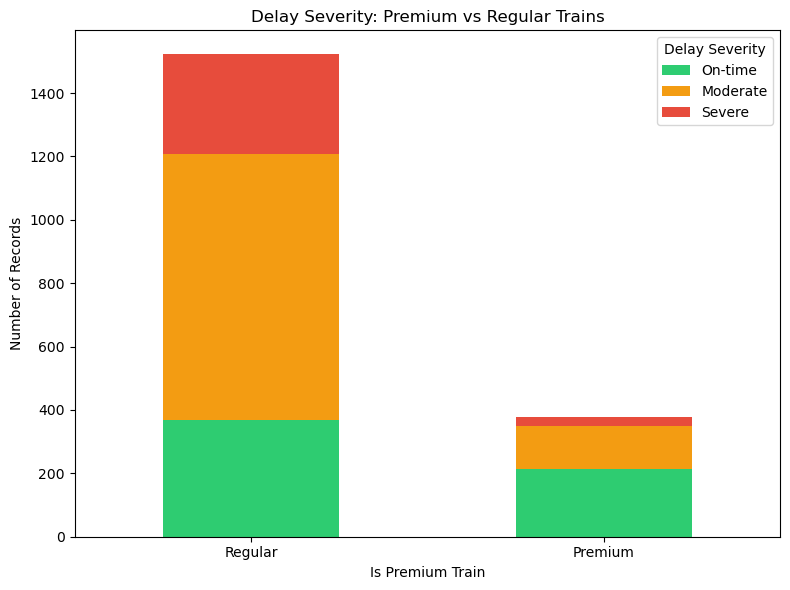

In [115]:
import matplotlib.pyplot as plt

crosstab_data = pd.crosstab(df['is_premium'], df['delay_severity'])
crosstab_data = crosstab_data[['On-time', 'Moderate', 'Severe']]  # reorder columns logically

crosstab_data.plot(kind='bar', stacked=True, color=['#2ecc71', '#f39c12', '#e74c3c'], figsize=(8,6))
plt.title('Delay Severity: Premium vs Regular Trains')
plt.xlabel('Is Premium Train')
plt.ylabel('Number of Records')
plt.xticks([0, 1], ['Regular', 'Premium'], rotation=0)
plt.legend(title='Delay Severity')
plt.tight_layout()
plt.savefig('premium_vs_regular_delay.png', dpi=150, bbox_inches='tight')
plt.show()

Bar heights reflect row counts, not proportions , Premium has fewer total records.t (1,491 regular rows vs 378 premium rows)

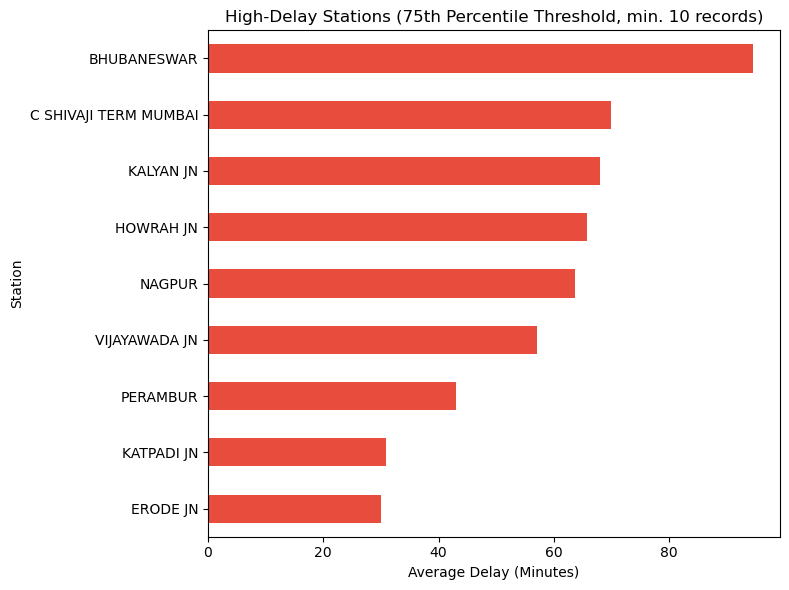

In [122]:
high_delay_stations = station_stats[station_stats['high_delay_station']].sort_values('mean', ascending=True)

high_delay_stations['mean'].plot(kind='barh', color='#e74c3c', figsize=(8,6))
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Station')
plt.title('High-Delay Stations (75th Percentile Threshold, min. 10 records)')
plt.tight_layout()
plt.savefig('high_delay_stations.png', dpi=150, bbox_inches='tight')
plt.show()

In [117]:
high_delay_stations

,mean,count,high_delay_station
station_name,,,
ERODE JN,30.100000,10,True
KATPADI JN,30.888889,18,True
PERAMBUR,43.100000,10,True
VIJAYAWADA JN,57.111111,18,True
NAGPUR,63.700000,10,True
HOWRAH JN,65.750000,20,True
KALYAN JN,67.944444,18,True
C SHIVAJI TERM MUMBAI,70.000000,12,True
BHUBANESWAR,94.500000,10,True


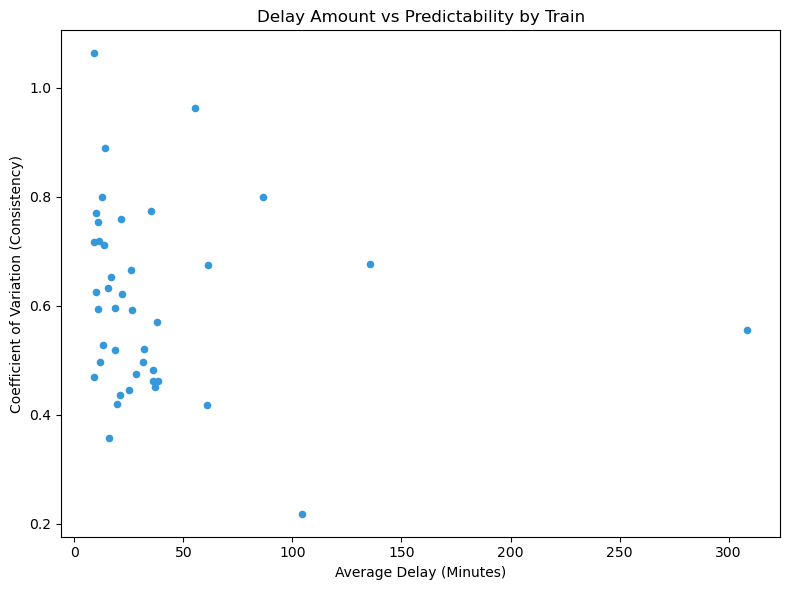

In [123]:
train_consistency['cv'] = train_consistency['std'] / train_consistency['mean']
plot_data = train_consistency[train_consistency['count'] >= 10]

plot_data.plot(x='mean', y='cv', kind='scatter', figsize=(8,6), color='#3498db')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Coefficient of Variation (Consistency)')
plt.title('Delay Amount vs Predictability by Train')
plt.tight_layout()
plt.savefig('delay_vs_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

In [124]:
plot_data[(plot_data['mean'] > 95) & (plot_data['mean'] < 115)]

,mean,std,count,cv
train_name,,,,
Howrah Mail,104.366197,22.829845,142,0.218748


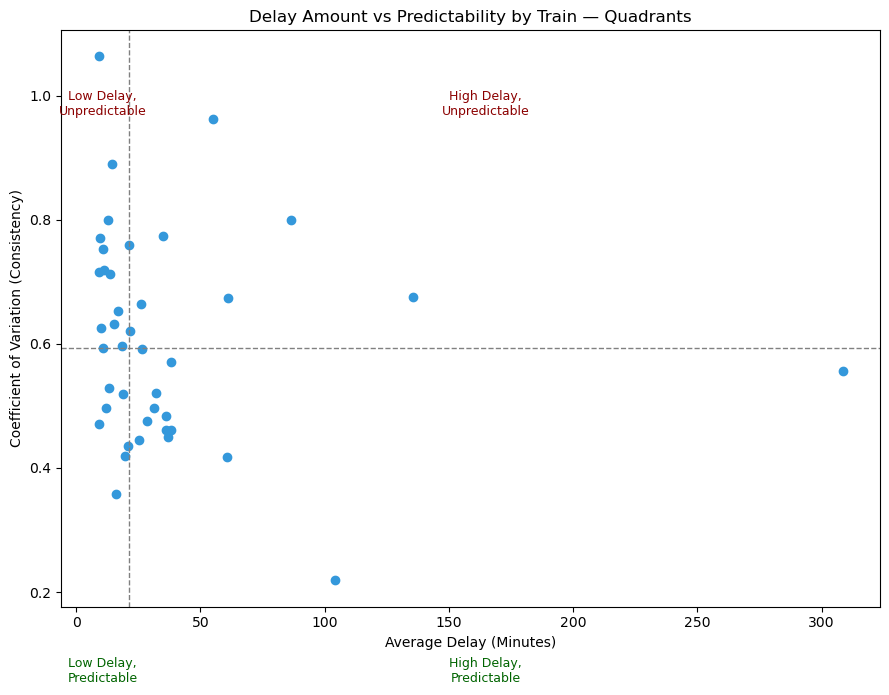

In [157]:
mean_median = plot_data['mean'].median()
cv_median = plot_data['cv'].median()

plt.figure(figsize=(9,7))
plt.scatter(plot_data['mean'], plot_data['cv'], color='#3498db')

plt.axvline(mean_median, color='gray', linestyle='--', linewidth=1)
plt.axhline(cv_median, color='gray', linestyle='--', linewidth=1)

plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Coefficient of Variation (Consistency)')
plt.title('Delay Amount vs Predictability by Train — Quadrants')

xmax = plot_data['mean'].max()
ymax = plot_data['cv'].max()

plt.text(mean_median/2, ymax*0.95, 'Low Delay,\nUnpredictable', ha='center', va='top', fontsize=9, color='darkred')
plt.text((mean_median+xmax)/2, ymax*0.95, 'High Delay,\nUnpredictable', ha='center', va='top', fontsize=9, color='darkred')
plt.text(mean_median/2, 0.05, 'Low Delay,\nPredictable', ha='center', va='bottom', fontsize=9, color='darkgreen')
plt.text((mean_median+xmax)/2, 0.05, 'High Delay,\nPredictable', ha='center', va='bottom', fontsize=9, color='darkgreen')

plt.tight_layout()
plt.savefig('delay_vs_consistency_quadrants.png', dpi=150, bbox_inches='tight')
plt.show()

In [127]:
import sqlite3
conn = sqlite3.connect('railway_data.db')
df.to_sql('train_delays', conn, if_exists='replace', index=False)

1900

In [128]:
pd.read_sql('SELECT * FROM train_delays LIMIT 5', conn)

,train_number,train_name,station_code,station_name,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown,scraped_at,source_url,is_premium,Corridor,delay_severity
0,12673,Cheran Express,MAS,CHENNAI CENTRAL,2.0,98.90,0.27,0.00,0.83,2025-09-27 12:25:37.767628+00:00,https://etrain.info/train/Cheran-Express-12673...,0,others,On-time
1,12673,Cheran Express,AVD,AVADI,0.0,0.27,0.00,0.00,99.73,2025-09-27 12:25:39.293769+00:00,https://etrain.info/train/Cheran-Express-12673...,0,others,On-time
2,12673,Cheran Express,AJJ,ARAKKONAM,16.0,55.34,44.38,0.27,0.01,2025-09-27 12:25:40.672610+00:00,https://etrain.info/train/Cheran-Express-12673...,0,others,Moderate
3,12673,Cheran Express,KPD,KATPADI JN,17.0,48.49,49.86,1.64,0.01,2025-09-27 12:25:42.125216+00:00,https://etrain.info/train/Cheran-Express-12673...,0,others,Moderate
4,12673,Cheran Express,JTJ,JOLARPETTAI,12.0,70.96,27.67,1.37,0.00,2025-09-27 12:25:44.585700+00:00,https://etrain.info/train/Cheran-Express-12673...,0,others,On-time


worst stations

In [129]:
query = """
SELECT station_name, 
       AVG(average_delay_minutes) as avg_delay,
       COUNT(*) as num_records
FROM train_delays
GROUP BY station_name
HAVING COUNT(*) >= 10
ORDER BY avg_delay DESC
LIMIT 10
"""
pd.read_sql(query, conn)


,station_name,avg_delay,num_records
0,BHUBANESWAR,94.500000,10
1,C SHIVAJI TERM MUMBAI,70.000000,12
2,KALYAN JN,67.944444,18
3,HOWRAH JN,65.750000,20
4,NAGPUR,63.700000,10
5,VIJAYAWADA JN,57.111111,18
6,PERAMBUR,43.100000,10
7,KATPADI JN,30.888889,18
8,ERODE JN,30.100000,10
9,SOLAPUR JN,29.900000,10


rank stations by delay within each severity category, using RANK():

In [130]:
query = """
SELECT station_name,
       average_delay_minutes,
       RANK() OVER (ORDER BY average_delay_minutes DESC) as delay_rank
FROM train_delays
LIMIT 15
"""
pd.read_sql(query, conn)

,station_name,average_delay_minutes,delay_rank
0,HOWRAH JN,586.0,1
1,TATANAGAR JN,530.0,2
2,KALYAN JN,482.0,3
3,C SHIVAJI TERM MUMBAI,468.0,4
4,AKOLA JN,448.0,5
5,AKOLA JN,411.0,6
6,BHUSAVAL JN,305.0,7
7,NAGPUR,305.0,7
8,BILASPUR JN,301.0,9
9,BILASPUR JN,298.0,10


for each station, find its single worst-recorded delay

In [131]:
query = """
SELECT station_name,
       average_delay_minutes,
       RANK() OVER (PARTITION BY station_name ORDER BY average_delay_minutes DESC) as rank_within_station
FROM train_delays
"""
result = pd.read_sql(query, conn)
result[result['rank_within_station'] == 1].sort_values('average_delay_minutes', ascending=False).head(10)

,station_name,average_delay_minutes,rank_within_station
694,HOWRAH JN,586.0,1
1675,TATANAGAR JN,530.0,1
801,KALYAN JN,482.0,1
317,C SHIVAJI TERM MUMBAI,468.0,1
34,AKOLA JN,448.0,1
1190,NAGPUR,305.0,1
261,BHUSAVAL JN,305.0,1
269,BILASPUR JN,301.0,1
948,KOKRAJHAR,252.0,1
281,BOLPUR S NIKTN,249.0,1


Delay trend across a train's route (LAG) :for each train, compare each station's delay to the previous station on its route, to see where delay actually accumulates:

In [135]:
query = """
SELECT train_name, station_name, average_delay_minutes,
       LAG(average_delay_minutes) OVER (PARTITION BY train_name ORDER BY station_code) as prev_station_delay,
       average_delay_minutes - LAG(average_delay_minutes) OVER (PARTITION BY train_name ORDER BY station_code) as delay_increase
FROM train_delays
ORDER BY train_name, station_code """
pd.read_sql(query, conn)

,train_name,station_name,average_delay_minutes,prev_station_delay,delay_increase
0,August Kranti Rajdhani,BHARUCH JN,15.0,NaN,NaN
1,August Kranti Rajdhani,BHARUCH JN,15.0,15.0,0.0
2,August Kranti Rajdhani,VALSAD,11.0,15.0,-4.0
3,August Kranti Rajdhani,VALSAD,14.0,11.0,3.0
4,August Kranti Rajdhani,VADODARA JN,10.0,14.0,-4.0
...,...,...,...,...,...
1895,Vikramshila Express,PATNA SAHEB,48.0,54.0,-6.0
1896,Vikramshila Express,PATNA SAHEB,56.0,48.0,8.0
1897,Vikramshila Express,PRAYAGRAJ JN,101.0,56.0,45.0
1898,Vikramshila Express,SULTANGANJ,12.0,101.0,-89.0


LAG() here unreliable as "delay accumulation along the route" — some of those delay_increase values (like that -89 for Vikramshila Express at Sultanganj) are likely just noise from comparing two different scrape records of the same station, not real station-to-station accumulation.

Two ways to fix this properly:

Deduplicate first — check if these repeated station rows per train are near-duplicates (maybe from different scrape timestamps) and collapse them to one row per train-station (e.g., average their delay) before running LAG().

Find a real ordering column — check if there's any column indicating actual sequence (distance from origin, station order number) rather than relying on station_code alphabetically/numerically.

In [137]:
query = """
SELECT train_name, station_name, COUNT(*) as num_occurrences
FROM train_delays
GROUP BY train_name, station_name
HAVING COUNT(*) > 1
ORDER BY num_occurrences DESC
LIMIT 15 """
pd.read_sql(query, conn)

,train_name,station_name,num_occurrences
0,Howrah Mail,ANAKAPALLE,4
1,Howrah Mail,ANNAVARAM,4
2,Howrah Mail,BALASORE,4
3,Howrah Mail,BALUGAN,4
4,Howrah Mail,BAPATLA,4
5,Howrah Mail,BHADRAKH,4
6,Howrah Mail,BHUBANESWAR,4
7,Howrah Mail,BRAHMAPUR,4
8,Howrah Mail,CHATRAPUR,4
9,Howrah Mail,CHENNAI CENTRAL,4


hat actually changes our fix: instead of "deduplicating" (which would suggest removing bad data), what we really want is to average across those 4 snapshots to get one representative delay value per train-station, before attempting any route-order analysis with LAG().

In [141]:
conn.execute("DROP TABLE IF EXISTS train_delays_avg")

create_query = """
CREATE TABLE train_delays_avg AS
SELECT train_name, station_name, station_code,
       AVG(average_delay_minutes) as avg_delay_minutes
FROM train_delays
GROUP BY train_name, station_name, station_code
"""
conn.execute(create_query)

pd.read_sql('SELECT * FROM train_delays_avg LIMIT 5', conn)

#conn.execute(...) is used for the two commands that don't return rows (DROP TABLE, CREATE TABLE) —
#we just want them to run silently. pd.read_sql(...) is used only for the final line, 
#a plain SELECT, which actually returns something for pandas to display as a table.

,train_name,station_name,station_code,avg_delay_minutes
0,August Kranti Rajdhani,BHARUCH JN,BH,15.00
1,August Kranti Rajdhani,BORIVALI,BVI,19.00
2,August Kranti Rajdhani,DAHOD,DHD,19.25
3,August Kranti Rajdhani,H NIZAMUDDIN,NZM,3.50
4,August Kranti Rajdhani,KOTA JN,KOTA,16.00


does station_code reflect the actual physical sequence of stations, or just alphabetical/arbitrary ordering

In [142]:
pd.read_sql("""
SELECT station_name, station_code, avg_delay_minutes
FROM train_delays_avg
WHERE train_name = 'August Kranti Rajdhani'
ORDER BY station_code
""", conn)

,station_name,station_code,avg_delay_minutes
0,BHARUCH JN,BH,15.00
1,VALSAD,BL,12.50
2,VADODARA JN,BRC,11.50
3,BORIVALI,BVI,19.00
4,DAHOD,DHD,19.25
5,KOTA JN,KOTA,16.00
6,MUMBAI CENTRAL,MMCT,8.50
7,MATHURA JN,MTJ,7.00
8,H NIZAMUDDIN,NZM,3.50
9,RATLAM JN,RTM,15.00


Confirmed — this is alphabetical by station code (BH, BL, BRC, BVI, DHD, KOTA, MMCT...), not route order. You can see it clearly: Mumbai Central (MMCT) and Borivali (BVI) — both near the Mumbai end of this route — are sitting far apart in this list (rows 3 and 6), while H Nizamuddin (Delhi end) sits in the middle at row 8. A real Mumbai→Delhi route wouldn't jump back and forth like that.

So the conclusion is clear: station_code cannot be used to determine actual route sequence — it's just sorted alphabetically. This means the LAG() "delay accumulation along the route" idea isn't valid with this dataset as it stands — there's no genuine sequence/distance column to order by.

This is a legitimate, honest limitatio

top 3 worst stations per train

In [153]:
query = """
WITH ranked AS (
    SELECT train_name, station_name, average_delay_minutes,
           RANK() OVER (PARTITION BY train_name ORDER BY average_delay_minutes DESC) as rnk
    FROM train_delays
)
SELECT * FROM ranked WHERE rnk <= 3 """
top3_per_train = pd.read_sql(query, conn)
pd.read_sql(query, conn)


,train_name,station_name,average_delay_minutes,rnk
0,August Kranti Rajdhani,BORIVALI,29.0,1
1,August Kranti Rajdhani,DAHOD,25.5,2
2,August Kranti Rajdhani,KOTA JN,23.0,3
3,August Kranti Rajdhani,VAPI,23.0,3
4,Chennai Express,THANE,54.0,1
...,...,...,...,...
132,Vande Bharat,BOLPUR S NIKTN,21.0,2
133,Vande Bharat,TAMBARAM,20.0,3
134,Vikramshila Express,PRAYAGRAJ JN,101.0,1
135,Vikramshila Express,BARHIYA,75.0,2


A reliability index
station's delay vs the overall network average


In [143]:
query = """
SELECT station_name, average_delay_minutes,
       AVG(average_delay_minutes) OVER () as overall_avg,
       average_delay_minutes - AVG(average_delay_minutes) OVER () as deviation_from_avg
FROM train_delays """
pd.read_sql(query, conn)

,station_name,average_delay_minutes,overall_avg,deviation_from_avg
0,CHENNAI CENTRAL,2.0,39.18542,-37.18542
1,AVADI,0.0,39.18542,-39.18542
2,ARAKKONAM,16.0,39.18542,-23.18542
3,KATPADI JN,17.0,39.18542,-22.18542
4,JOLARPETTAI,12.0,39.18542,-27.18542
...,...,...,...,...
1895,MADGAON,35.0,39.18542,-4.18542
1896,RATNAGIRI,66.0,39.18542,26.81458
1897,PANVEL,41.0,39.18542,1.81458
1898,THANE,45.0,39.18542,5.81458


couple of interesting extremes jump out: Avadi (-39.19 deviation, essentially 0 delay) sits about as far below average as mathematically possible, while Ratnagiri (+26.8 deviation, 66 min delay) is a genuine standout on the high side.

In [151]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,train_delays
1,train_delays_avg


In [144]:
df.to_csv('railway_data_cleaned.csv', index=False)

In [148]:
top3_per_train.to_csv('top3_delays_per_train.csv', index=False)  # or whatever you named that dataframe

In [155]:
station_stats.to_csv('station_stats.csv')

In [156]:
top3_per_train.to_csv('top3_per_train.csv', index=False)